In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [12]:
# change paths as needed

data_path = r"C:/Users/r889990/Trading/ETFS/RES_fx/Data/"


wti_hourly = pd.read_csv(data_path+"cl-1h_bk.csv", sep=";", header=None)
brt_hourly = pd.read_csv(data_path+"cb-1h_bk.csv", sep=";", header=None)
hh_hourly =  pd.read_csv(data_path+"ng-1h_bk.csv", sep=";", header=None)
YSN_hourly =  pd.read_csv(data_path+"YSN_h.DE.csv", sep=";", header=None)



In [13]:
YSN_hourly

,0,1,2,3,4,5,6
0,Date,Time,Open,High,Low,Close,Volume
1,2023-06-05,13:00,"196,000","197,200","196,000","197,200",0
2,2023-06-05,14:00,"195,400","195,800","194,200","195,400",292
3,2023-06-05,15:00,"197,000","197,400","196,200","196,200",196
4,2023-06-06,07:00,"195,400","195,800","195,200","195,800",0
...,...,...,...,...,...,...,...
4244,2025-06-04,07:00,"222,500","224,000","220,500","222,000",1041
4245,2025-06-04,08:00,"224,000","225,500","223,000","223,000",2454
4246,2025-06-04,09:00,"222,500","225,000","222,500","224,000",467
4247,2025-06-04,10:00,"222,500","223,500","221,500","223,500",198


In [ ]:

for df in [YSN_hourly,]:
    df.columns = ['Date', 'Time', 'Open', 'High', 'Low', 'Close', 'Volume']
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d').dt.date
    df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.time
    df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
    df.set_index('Datetime', inplace=True)
    df.interpolate(method='time')
    df.drop(columns=['Date', 'Time'], inplace=True)
    df.index = df.index.tz_localize(None)
    df.index = df.index.tz_localize('America/Chicago')
    df.index = df.index.tz_convert('Europe/Berlin')
    df.index = df.index.tz_localize(None)
    

In [ ]:
df

In [10]:
wti_daily = wti_hourly.resample('D').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
brt_daily = brt_hourly.resample('D').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
hh_daily =   hh_hourly.resample('D').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()

wti_weekly = wti_hourly.resample('W').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
brt_weekly = brt_hourly.resample('W').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna() 
hh_weekly =   hh_hourly.resample('W').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()

In [11]:
def add_moving_average_col(df, period):
    df[f'MA_{period}'] = df['Close'].rolling(window=period).mean()

In [12]:
def add_returns_col(df):
    df['Returns'] = df['Close'].pct_change()

def add_log_returns_col(df):
    df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

def add_volatility_col(df, period):
    df[f'Volatility_{period}'] = df['Log_Returns'].rolling(window=period).std() * np.sqrt(period)
    df.dropna(inplace=True)

In [ ]:
brt_daily

In [22]:
df_list = [wti_hourly, brt_hourly, hh_hourly, wti_daily, brt_daily, hh_daily, wti_weekly, brt_weekly, hh_weekly]

# change start date here
start_date = pd.to_datetime('2018-01-01')

start_date_II = pd.to_datetime('2018-11-10')

for df in df_list:
    add_moving_average_col(df, 10)
    add_moving_average_col(df, 20)
    add_moving_average_col(df, 50)
    add_returns_col(df)
    add_log_returns_col(df)
    mask = df.index < start_date
    df.drop(df.index[mask], inplace=True)




In [33]:
mask= brt_hourly.index < start_date_II
brt_hourly.drop(brt_hourly.index[mask], inplace=True)


In [ ]:
wti_hourly = brt_hourly.align(brt_hourly)


In [35]:
wti_hourly

,Open,High,Low,Close,Volume,MA_10,MA_20,MA_50,Returns,Log_Returns
Datetime,,,,,,,,,,
2018-11-12 00:00:00,50.585613,50.857540,50.471117,50.814604,3588.0,50.088988,50.168419,50.848237,0.016171,0.016041
2018-11-12 01:00:00,50.814604,50.900476,50.778824,50.821760,1233.0,50.207062,50.180227,50.834212,0.000141,0.000141
2018-11-12 02:00:00,50.821760,50.850384,50.657173,50.743045,2673.0,50.249282,50.187741,50.816751,-0.001549,-0.001550
2018-11-12 03:00:00,50.728733,50.850384,50.707265,50.836072,1092.0,50.333723,50.194181,50.803441,0.001833,0.001832
2018-11-12 04:00:00,50.843228,50.879008,50.800292,50.879008,1314.0,50.406714,50.209924,50.790703,0.000845,0.000844
...,...,...,...,...,...,...,...,...,...,...
2025-05-13 23:00:00,66.540000,66.610000,66.420000,66.600000,351.0,66.369000,65.720000,65.193200,0.000751,0.000751
2025-05-14 02:00:00,66.560000,66.590000,66.380000,66.390000,989.0,66.428000,65.803000,65.242800,-0.003153,-0.003158
2025-05-14 03:00:00,66.390000,66.450000,66.270000,66.340000,2175.0,66.498000,65.882000,65.292800,-0.000753,-0.000753


In [15]:
def add_event_col(df, period, Y):
    """
    df: price dataframe
    period: moving average period ∈ [10, 20, 50]
    Y: periods after MA crossover
    """
    above_ma = df['Close'] > df[f'MA_{period}']
    exact_above = (above_ma.rolling(Y).sum() == Y) & (~above_ma.shift(Y).fillna(False))
    df[f'above_{period}MA_for_{Y}'] = exact_above
    

In [16]:
# OPTIONS
############################
selected_df = brt_daily
period = 10                  # moving average period
Y = 2                        # periods above MA after crossover
############################

add_event_col(selected_df, period, Y)

C:\Users\r889990\AppData\Local\Temp\ipykernel_27092\2158516692.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  exact_above = (above_ma.rolling(Y).sum() == Y) & (~above_ma.shift(Y).fillna(False))


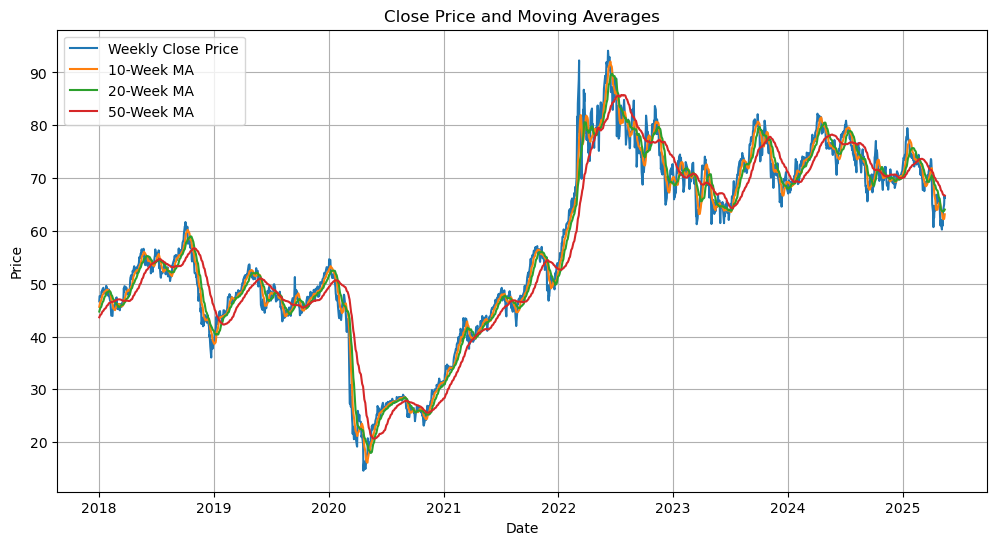

In [79]:
plt.figure(figsize=(12, 6))
plt.plot(selected_df['Close'], label='Weekly Close Price')
plt.plot(selected_df['MA_10'], label='10-Week MA')
plt.plot(selected_df['MA_20'], label='20-Week MA')
plt.plot(selected_df['MA_50'], label='50-Week MA')
plt.title('Close Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

In [80]:
horizons = (5, 7, 10, 14, 20, 30, 50)
# horizons = (1, 2, 3, 4, 5, 10, 20)
returns_full = {}
returns_event = {}

for h in horizons:
    returns_full[h] = np.log(selected_df['Close'].shift(-h)) - np.log(selected_df['Close'])
    returns_event[h] = np.log(selected_df['Close'].shift(-h).loc[selected_df[f'above_{period}MA_for_{Y}']]) - np.log(selected_df['Close'].loc[selected_df[f'above_{period}MA_for_{Y}']])

In [81]:
def event_stats(df, ma_period, momentum_period, horizons=(7,14,28,42,56)): 
    
    event_col = f'above_{ma_period}MA_for_{momentum_period}'
    if event_col not in df.columns:
        add_event_col(df, ma_period, momentum_period)

    rows = []
    for h in horizons:
        pop = returns_full[h].dropna()
        evt = returns_event[h].dropna()

        n_evt    = len(evt)
        n_pop    = len(pop)
        mean_evt = evt.mean() if n_evt>0 else np.nan
        mean_pop = pop.mean() if n_pop>0 else np.nan

        # pooled z-score
        if n_evt>1 and n_pop>1:
            s_evt  = evt.std(ddof=1)
            s_pop  = pop.std(ddof=1)
            pooled = np.sqrt((s_evt**2 + s_pop**2) / 2)
            cohens_d = (mean_evt - mean_pop) / pooled
        else:
            cohens_d = np.nan

        if n_evt>1 and n_pop>1:
            t_stat, p_val = ttest_ind(evt, pop, equal_var=False)
        else:
            t_stat, p_val = np.nan, np.nan

        rows.append({
            'horizon':         h,
            'n_events':        n_evt,
            'n_population':    n_pop,
            'mean_event':      mean_evt,
            'mean_population': mean_pop,
            'cohens_d':        cohens_d,
            't_stat':          t_stat,
            'p_value':         p_val
        })

    return pd.DataFrame(rows).set_index('horizon')

In [82]:
stats_above = event_stats(selected_df,
    ma_period=period,
    momentum_period=Y,
    horizons=horizons,
)
stats_above


,n_events,n_population,mean_event,mean_population,cohens_d,t_stat,p_value
horizon,,,,,,,
5,122,1924,-0.001813,0.000818,-0.051255,-0.586719,0.558323
7,122,1922,0.001363,0.001066,0.004919,0.056838,0.954754
10,122,1919,0.002172,0.001419,0.010286,0.116714,0.907252
14,122,1915,0.003813,0.001989,0.020551,0.226182,0.821392
20,121,1909,0.006888,0.002923,0.038932,0.450235,0.653226
30,121,1899,0.019645,0.004684,0.118407,1.393195,0.165707
50,120,1879,0.028722,0.009287,0.109941,1.266654,0.207362


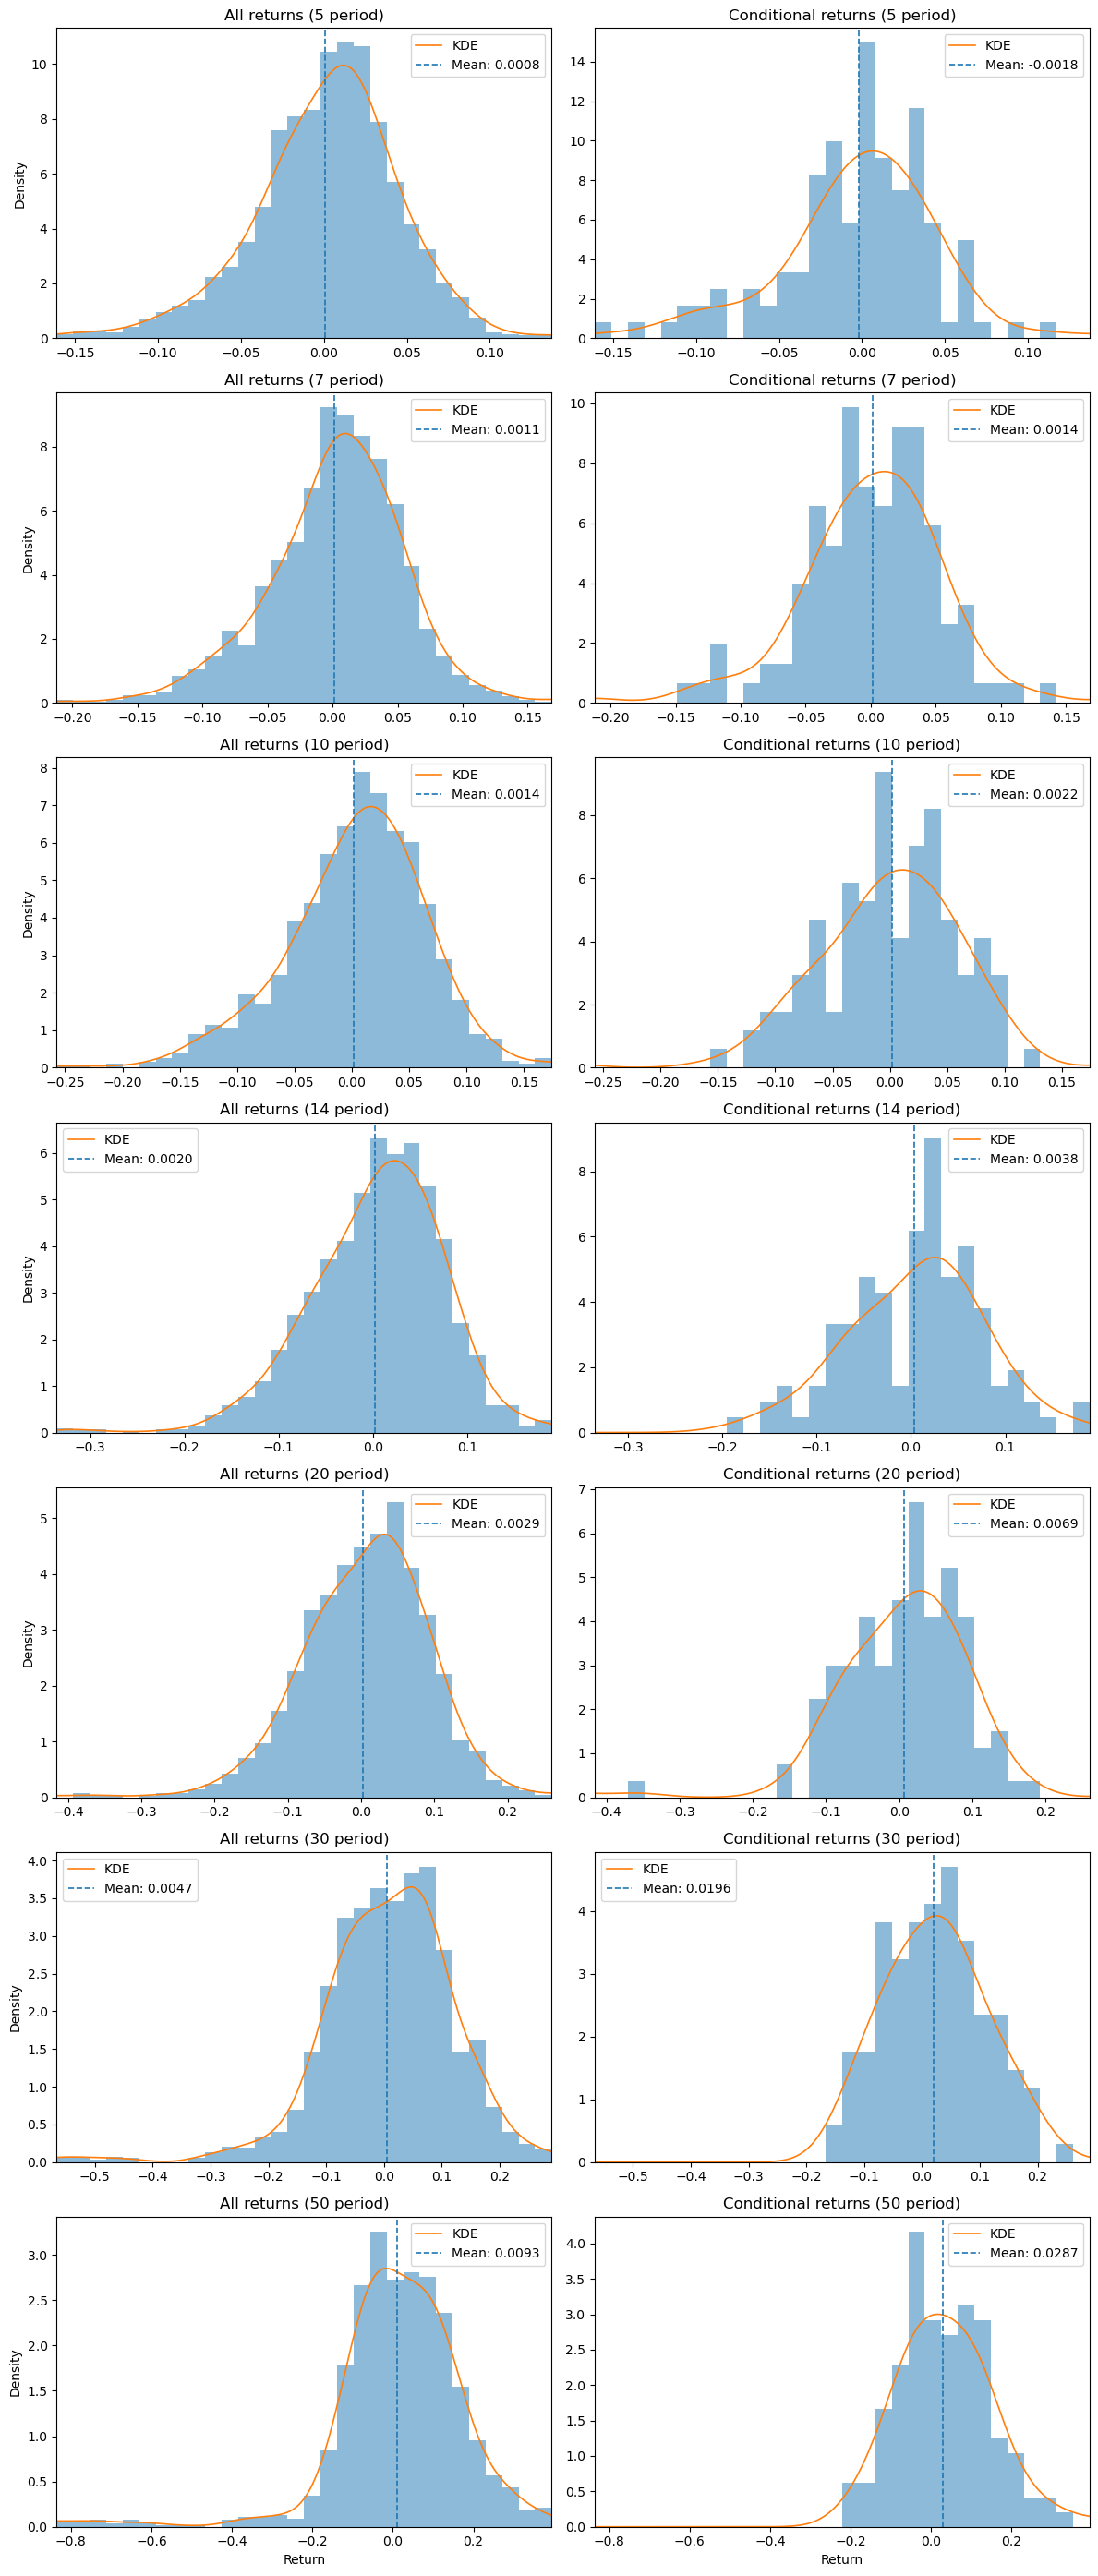

In [83]:
from scipy.stats import gaussian_kde

def plot_histograms_per_horizon(returns_full, returns_event, horizons,
                                percentiles=(1, 99), nbins=50):

    fig, axes = plt.subplots(
        nrows=len(horizons), ncols=2,
        figsize=(12, 4 * len(horizons)),
        sharex='row'
    )

    for i, h in enumerate(horizons):
        ax_all, ax_cond = axes[i]

        data_full  = returns_full[h].dropna().values
        data_event = returns_event[h].dropna().values

        lo, hi = np.percentile(
            np.concatenate([data_full, data_event]), percentiles
        )
        bins = np.linspace(lo, hi, nbins + 1)

        ax_all.hist(data_full, bins=bins, range=(lo, hi), density=True, alpha=0.5)
        ax_cond.hist(data_event, bins=bins, range=(lo, hi), density=True, alpha=0.5)

        xs = np.linspace(lo, hi, 200)
        ax_all.plot(xs, gaussian_kde(data_full)(xs), linewidth=1.2, label='KDE')
        ax_cond.plot(xs, gaussian_kde(data_event)(xs), linewidth=1.2, label='KDE')

        mean_full = data_full.mean()
        mean_event = data_event.mean()
        ax_all.axvline(mean_full, linestyle='--', linewidth=1.2, label=f'Mean: {mean_full:.4f}')
        ax_cond.axvline(mean_event, linestyle='--', linewidth=1.2, label=f'Mean: {mean_event:.4f}')

        ax_all.set_xlim(lo, hi)
        ax_cond.set_xlim(lo, hi)
        ax_all.set_title(f'All returns ({h} period)')
        ax_cond.set_title(f'Conditional returns ({h} period)')
        if i == len(horizons) - 1:
            ax_all.set_xlabel('Return')
            ax_cond.set_xlabel('Return')
        ax_all.set_ylabel('Density')

        ax_all.legend()
        ax_cond.legend()

    plt.tight_layout()
    plt.show()

plot_histograms_per_horizon(returns_full, returns_event, horizons, nbins=30)
